# Intro

# Imports

In [1]:
%load_ext autoreload
%autoreload 2

from echofit import EchoFit


/Users/david/Library/Caches/pypoetry/virtualenvs/echofit-W-NSutmR-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Create an echofit instance

In [2]:
fit = EchoFit()


# Data Ingestion

In [3]:
fit.load_csv("xray", "../data/xray.csv")
fit.load_csv("uv", "../data/uv.csv", wavelength=1500)
fit.load_csv("optical", "../data/optical.csv", wavelength=5000)

# Plot raw light curves

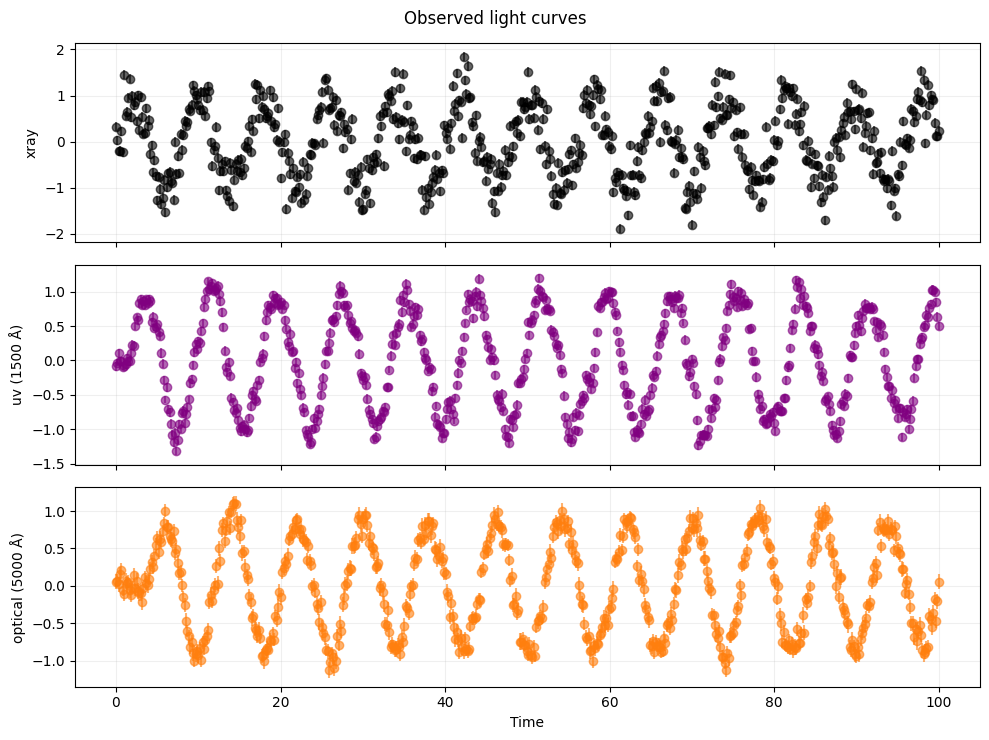

In [4]:
fit.plot_raw_lightcurve_data(normalize=False, errorbars=True, title="Observed light curves")

# Diagnose bugs

# Run

In [5]:
import jax.numpy as jnp

from echofit.forward import build_design_matrix
fit.build_context()
ctx = fit.ctx
A = build_design_matrix(
    ctx.cache,
    ctx.X,
    ctx,
    params=(6.0, 0.1, 45.0),  # example disk params
)
Q, R = jnp.linalg.qr(A)
A = Q

print("A shape:", A.shape)
print("cond(A):", jnp.linalg.cond(A))
print("max A:", jnp.max(jnp.abs(A)))

A shape: (1200, 80)
cond(A): 1.0000006
max A: 0.40606636


In [6]:
fit.run_mcmc(num_warmup=10, num_samples=5)

sample: 100%|██████████| 15/15 [00:05<00:00,  2.71it/s, 1 steps of size 1.69e-04. acc. prob=0.00]


=== BETA DEBUG ===
beta_mean: [ 0.8326971   0.64605516  0.8924357   0.31461608  1.6918834   0.6607596
  0.16511618  1.42332     0.37704045 -0.82225573 -1.1469291  -1.0019959
 -0.1345334   1.7987388   1.664019    1.905049    0.18880254  1.4722477
 -0.5234459  -0.4456559   0.6550385   0.9207487   0.04120627 -0.15036121
 -1.8905423   0.28232357  0.11019959 -0.49552187 -0.52336514  0.95797837
 -0.6147225   1.0416481  -0.8908421  -1.0879058  -0.75907964  0.3233052
  0.6364574  -0.6698915   0.6168405   0.83028334 -0.52308124  0.9200924
 -0.38652548  1.5002218   1.7661136  -0.43295175  1.6679577   0.02384644
 -0.14973067 -0.7801239  -0.64491     1.2787867  -0.04013838 -0.6469207
  0.19255647  1.2795172  -0.6861898   0.29929143 -1.7451576   1.7689743
  1.641302   -1.3977463   0.76012766 -1.6254834   0.17751387 -0.5352439
 -1.540837   -1.4117973   1.7879406  -1.1116008  -1.2826432  -1.9717492
 -0.01065333  0.29567167  0.7123129   0.7075728  -1.4948438  -0.56675714
 -1.7601894   1.5697448 ]
norm

/Users/david/Library/Caches/pypoetry/virtualenvs/echofit-W-NSutmR-py3.11/lib/python3.11/site-packages/arviz/data/base.py:221: UserWarning: More chains (5) than draws (2). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


# Convergence Diagnostics

/Users/david/Library/Caches/pypoetry/virtualenvs/echofit-W-NSutmR-py3.11/lib/python3.11/site-packages/arviz/stats/density_utils.py:487: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/Users/david/Library/Caches/pypoetry/virtualenvs/echofit-W-NSutmR-py3.11/lib/python3.11/site-packages/arviz/stats/density_utils.py:487: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/Users/david/Library/Caches/pypoetry/virtualenvs/echofit-W-NSutmR-py3.11/lib/python3.11/site-packages/arviz/stats/density_utils.py:487: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/Users/david/Library/Caches/pypoetry/virtualenvs/echofit-W-NSutmR-py3.11/lib/python3.11/site-packages/arviz/stats/density_utils.py

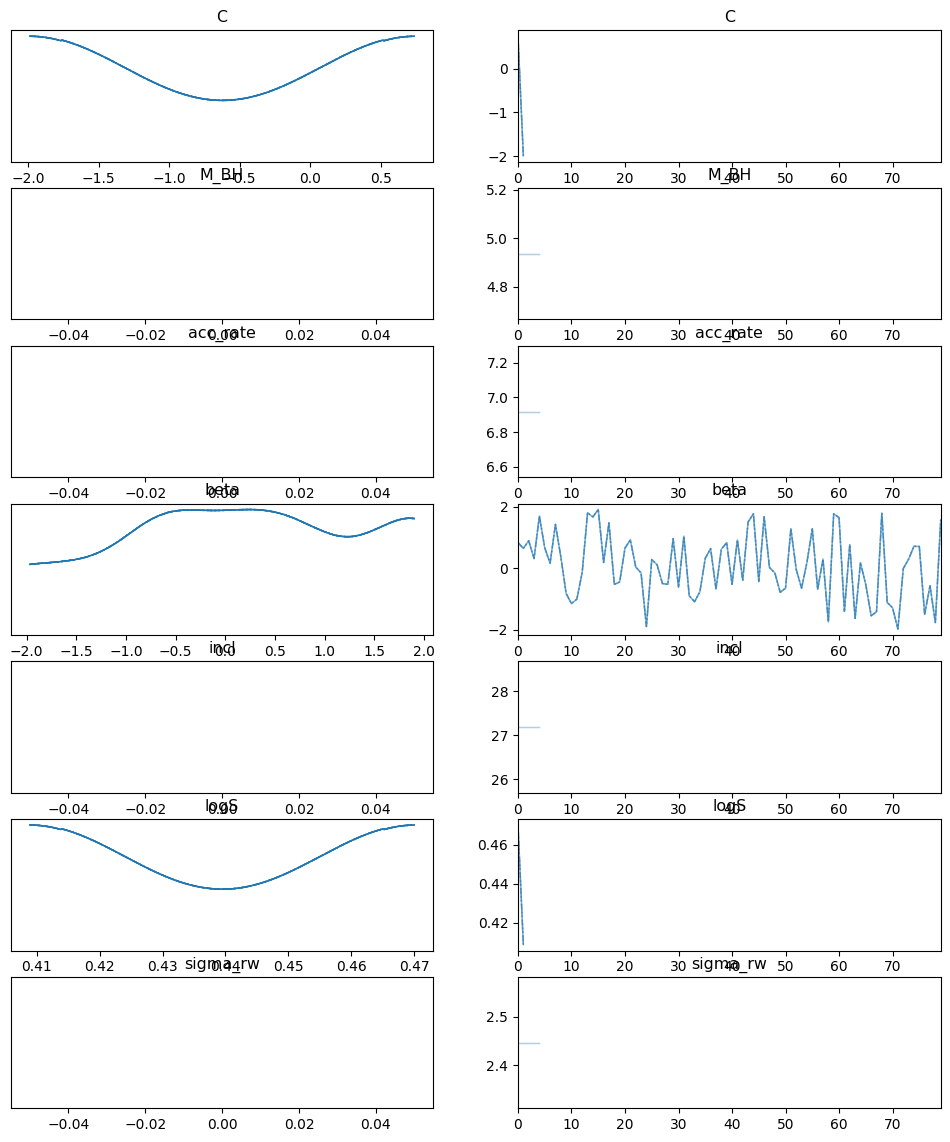

arviz - WARNING - Array contains NaN-value.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
C,NaN,NaN,-1.989,NaN,NaN,NaN,NaN,NaN,NaN
M_BH,NaN,NaN,4.936,NaN,NaN,NaN,NaN,NaN,NaN
acc_rate,NaN,NaN,6.919,NaN,NaN,NaN,NaN,NaN,NaN
beta,0.086,1.047,-1.625,1.905,0.055,0.044,334.0,384.0,1.01
incl,NaN,NaN,27.189,NaN,NaN,NaN,NaN,NaN,NaN
logS,NaN,NaN,0.409,NaN,NaN,NaN,NaN,NaN,NaN
sigma_rw,NaN,NaN,2.447,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
fit.plot_trace()
fit.summary()


# Posterior Dstributions

In [8]:
import numpy as np
for k, v in fit.samples.items():
    v = np.array(v)
    print(k, "NaNs:", np.isnan(v).sum(), "mean:", np.nanmean(v))

C NaNs: 0 mean: -0.62460923
M_BH NaNs: 0 mean: 4.936025
acc_rate NaNs: 0 mean: 6.918721
beta NaNs: 0 mean: 0.08620041
incl NaNs: 0 mean: 27.188807
logS NaNs: 0 mean: 0.43946844
sigma_rw NaNs: 0 mean: 2.446888


In [9]:
fit.plot_posteriors()

/Users/david/Library/Caches/pypoetry/virtualenvs/echofit-W-NSutmR-py3.11/lib/python3.11/site-packages/arviz/stats/density_utils.py:487: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")


# Light curve fits

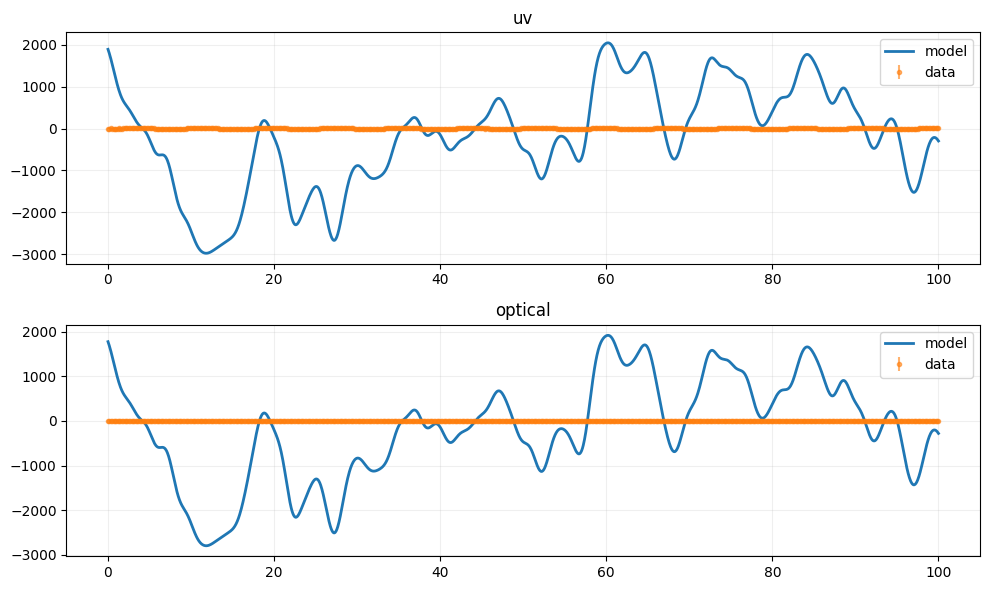

In [10]:
fit.plot_lightcurves()

# diagnostics

In [11]:
import time
import jax
from echofit.forward import forward_model

ctx = fit.ctx

params = (6.0, 0.1, 45.0)
sigma_rw = 1.0

C = jax.numpy.ones(len(ctx.bands))
S = jax.numpy.ones(len(ctx.bands))

# warmup (IMPORTANT)
_ = forward_model(
    ctx.cache,
    ctx.X,
    ctx.t_model,
    ctx.interp_idx,
    ctx,
    params,
    sigma_rw,
    C,
    S,
)

jax.block_until_ready(_)

# timed run
t0 = time.time()

for _ in range(10):
    y = forward_model(
        ctx.cache,
        ctx.X,
        ctx.t_model,
        ctx.interp_idx,
        ctx,
        params,
        sigma_rw,
        C,
        S,
    )

jax.block_until_ready(y)

t1 = time.time()

print("avg forward time:", (t1 - t0)/10)

# avg forward time: 0.05300607681274414


ImportError: cannot import name 'forward_model' from 'echofit.forward' (/Users/david/projects/datascience_projects/echofit/src/echofit/forward.py)

In [ ]:
import time

import numpyro
from echofit.inference import model

ctx = fit.ctx

m = model(ctx)

# compile warmup
_ = numpyro.handlers.seed(m, jax.random.PRNGKey(0))
_ = numpyro.handlers.trace(_).get_trace()

# timing run
t0 = time.time()
fit.run_mcmc(num_warmup=50, num_samples=50)
t1 = time.time()

print("MCMC time:", t1 - t0)

warmup:  12%|█▏        | 12/100 [01:12<22:55, 15.63s/it, 511 steps of size 8.08e-04. acc. prob=0.55]